**Tugas:** Making UI from my 10 dataset public

**Nama:** Faysal Abdullahi Yusuf

:1. Install & Import Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from IPython.display import display

print("Libraries loaded successfully!")


Libraries loaded successfully!


 2. Dataset — 10 Mall Customers

In [9]:
# Task 1 – Dataset
data = {
    'ID':       ['C1',  'C2',  'C3',  'C4',  'C5',  'C6',   'C7',   'C8',  'C9',  'C10'],
    'Customer': ['Budi','Siti','Andi','Dewi','Reza','Laras','Hendra','Maya','Tono','Fira'],
    'Income':   [20,    22,    25,    21,    80,    85,     90,     82,    55,    50],
    'Score':    [70,    75,    80,    72,    15,    12,     10,     18,    50,    45],
    'Notes':    ['Low income, High spend','Low income, High spend',
                 'Low income, High spend','Low income, High spend',
                 'High income, Low spend','High income, Low spend',
                 'High income, Low spend','High income, Low spend',
                 'Mid income, Mid spend', 'Mid income, Mid spend'],
}

df = pd.DataFrame(data)
df.index = df['ID']

# Style the table
def highlight_cluster(row):
    if row['ID'] in ['C1','C2','C3','C4','C9','C10']:
        return ['background-color: #dbeafe; color: #1e3a5f'] * len(row)
    else:
        return ['background-color: #fef3c7; color: #78350f'] * len(row)

display(df.style.apply(highlight_cluster, axis=1).set_caption("Mall Customer Dataset"))
print(f"\nTotal customers: {len(df)}")
print(f"Features: Annual Income (k$), Spending Score (1-100)")


,ID,Customer,Income,Score,Notes
ID,,,,,
C1,C1,Budi,20,70,"Low income, High spend"
C2,C2,Siti,22,75,"Low income, High spend"
C3,C3,Andi,25,80,"Low income, High spend"
C4,C4,Dewi,21,72,"Low income, High spend"
C5,C5,Reza,80,15,"High income, Low spend"
C6,C6,Laras,85,12,"High income, Low spend"
C7,C7,Hendra,90,10,"High income, Low spend"
C8,C8,Maya,82,18,"High income, Low spend"
C9,C9,Tono,55,50,"Mid income, Mid spend"



Total customers: 10
Features: Annual Income (k$), Spending Score (1-100)



 3. K-Means Calculation (Manual, K=2)

In [10]:
def euclidean(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

X = df[['Income','Score']].values
ids = df['ID'].values

# Initial centroids: C1=(20,70), C2=(90,10)
centroid1 = np.array([20.0, 70.0])
centroid2 = np.array([90.0, 10.0])

print("=" * 60)
print("INITIAL CENTROIDS")
print(f"  Centroid 1 (from C1): {centroid1}")
print(f"  Centroid 2 (from C7): {centroid2}")

def run_iteration(X, ids, c1, c2, iteration_num):
    print(f"\n{'='*60}")
    print(f"ITERATION {iteration_num}")
    print(f"  Centroid 1: {np.round(c1,3)}  |  Centroid 2: {np.round(c2,3)}")
    print(f"{'─'*60}")
    print(f"  {'ID':<5} {'X1':>6} {'X2':>6} {'d(C1)':>10} {'d(C2)':>10}  Assigned")
    print(f"{'─'*60}")

    clusters = []
    for i, (x, cid) in enumerate(zip(X, ids)):
        d1 = euclidean(x, c1)
        d2 = euclidean(x, c2)
        assigned = 1 if d1 <= d2 else 2
        clusters.append(assigned)
        tag = "← ✓" if d1 < d2 else ("← ✓" if d2 < d1 and assigned==2 else "  ✓")
        a1 = f"{d1:>10.4f}"
        a2 = f"{d2:>10.4f}"
        print(f"  {cid:<5} {x[0]:>6} {x[1]:>6} {a1} {a2}  Cluster {assigned}")

    clusters = np.array(clusters)

    # Update centroids
    c1_pts = X[clusters==1]
    c2_pts = X[clusters==2]
    new_c1 = c1_pts.mean(axis=0) if len(c1_pts) else c1
    new_c2 = c2_pts.mean(axis=0) if len(c2_pts) else c2

    print(f"{'─'*60}")
    print(f"  Updated Centroid 1: {np.round(new_c1,6)}")
    print(f"  Updated Centroid 2: {np.round(new_c2,6)}")
    print(f"  Cluster 1 members: {list(ids[clusters==1])}")
    print(f"  Cluster 2 members: {list(ids[clusters==2])}")

    return clusters, new_c1, new_c2

# Iteration 1
clusters1, new_c1, new_c2 = run_iteration(X, ids, centroid1, centroid2, 1)

# Iteration 2
clusters2, final_c1, final_c2 = run_iteration(X, ids, new_c1, new_c2, 2)

# Check convergence
if np.array_equal(clusters1, clusters2):
    print("\n" + "="*60)
    print("CONVERGED after 2 iterations — no membership change!")
else:
    print("\n Not converged yet, more iterations needed.")

df['Cluster'] = clusters2


INITIAL CENTROIDS
  Centroid 1 (from C1): [20. 70.]
  Centroid 2 (from C7): [90. 10.]

ITERATION 1
  Centroid 1: [20. 70.]  |  Centroid 2: [90. 10.]
────────────────────────────────────────────────────────────
  ID        X1     X2      d(C1)      d(C2)  Assigned
────────────────────────────────────────────────────────────
  C1        20     70     0.0000    92.1954  Cluster 1
  C2        22     75     5.3852    94.0691  Cluster 1
  C3        25     80    11.1803    95.5249  Cluster 1
  C4        21     72     2.2361    92.7631  Cluster 1
  C5        80     15    81.3941    11.1803  Cluster 2
  C6        85     12    87.1149     5.3852  Cluster 2
  C7        90     10    92.1954     0.0000  Cluster 2
  C8        82     18    80.9197    11.3137  Cluster 2
  C9        55     50    40.3113    53.1507  Cluster 1
  C10       50     45    39.0512    53.1507  Cluster 1
────────────────────────────────────────────────────────────
  Updated Centroid 1: [32.166667 65.333333]
  Updated Centroid 2

4. Silhouette Score Evaluation

In [11]:
print("=" * 65)
print("SILHOUETTE SCORE EVALUATION")
print("Formula: s(i) = (b(i) - a(i)) / max(a(i), b(i))")
print("=" * 65)

def silhouette_scores(X, ids, clusters):
    n = len(X)
    scores = []
    a_vals, b_vals = [], []

    for i in range(n):
        same    = [j for j in range(n) if clusters[j] == clusters[i] and j != i]
        diff    = [j for j in range(n) if clusters[j] != clusters[i]]

        a = np.mean([euclidean(X[i], X[j]) for j in same]) if same else 0
        b = np.mean([euclidean(X[i], X[j]) for j in diff]) if diff else 0
        s = (b - a) / max(a, b) if max(a, b) > 0 else 0

        a_vals.append(a); b_vals.append(b); scores.append(s)

    return np.array(a_vals), np.array(b_vals), np.array(scores)

a_vals, b_vals, s_vals = silhouette_scores(X, ids, clusters2)

print(f"\n{'ID':<5} {'Cluster':<10} {'a(i)':>9} {'b(i)':>9} {'max(a,b)':>10} {'s(i)':>8}")
print("─" * 55)
for i, cid in enumerate(ids):
    print(f"{cid:<5} Cluster {clusters2[i]:<3} {a_vals[i]:>9.4f} {b_vals[i]:>9.4f} {max(a_vals[i],b_vals[i]):>10.4f} {s_vals[i]:>8.4f}")

overall = s_vals.mean()
print("─" * 55)
print(f"{'Overall Silhouette Score':>44}: {overall:.6f}")
print()
if overall >= 0.7:
    print("Excellent clustering (≥ 0.7) — clusters are well separated!")
elif overall >= 0.5:
    print("Good clustering (≥ 0.5)")
else:
    print(" Weak clustering (< 0.5)")


SILHOUETTE SCORE EVALUATION
Formula: s(i) = (b(i) - a(i)) / max(a(i), b(i))

ID    Cluster         a(i)      b(i)   max(a,b)     s(i)
───────────────────────────────────────────────────────
C1    Cluster 1     19.6328   85.4060    85.4060   0.7701
C2    Cluster 1     19.3631   87.3435    87.3435   0.7783
C3    Cluster 1     22.2787   88.8945    88.8945   0.7494
C4    Cluster 1     18.8926   85.9986    85.9986   0.7803
C5    Cluster 2      6.8723   69.5777    69.5777   0.9012
C6    Cluster 2      5.9748   75.1904    75.1904   0.9205
C7    Cluster 2      9.2931   80.1423    80.1423   0.8840
C8    Cluster 2      7.2092   68.8506    68.8506   0.8953
C9    Cluster 1     34.3412   46.6115    46.6115   0.2632
C10   Cluster 1     33.9587   46.3875    46.3875   0.2679
───────────────────────────────────────────────────────
                    Overall Silhouette Score: 0.721041

Excellent clustering (≥ 0.7) — clusters are well separated!


5. Visualizations

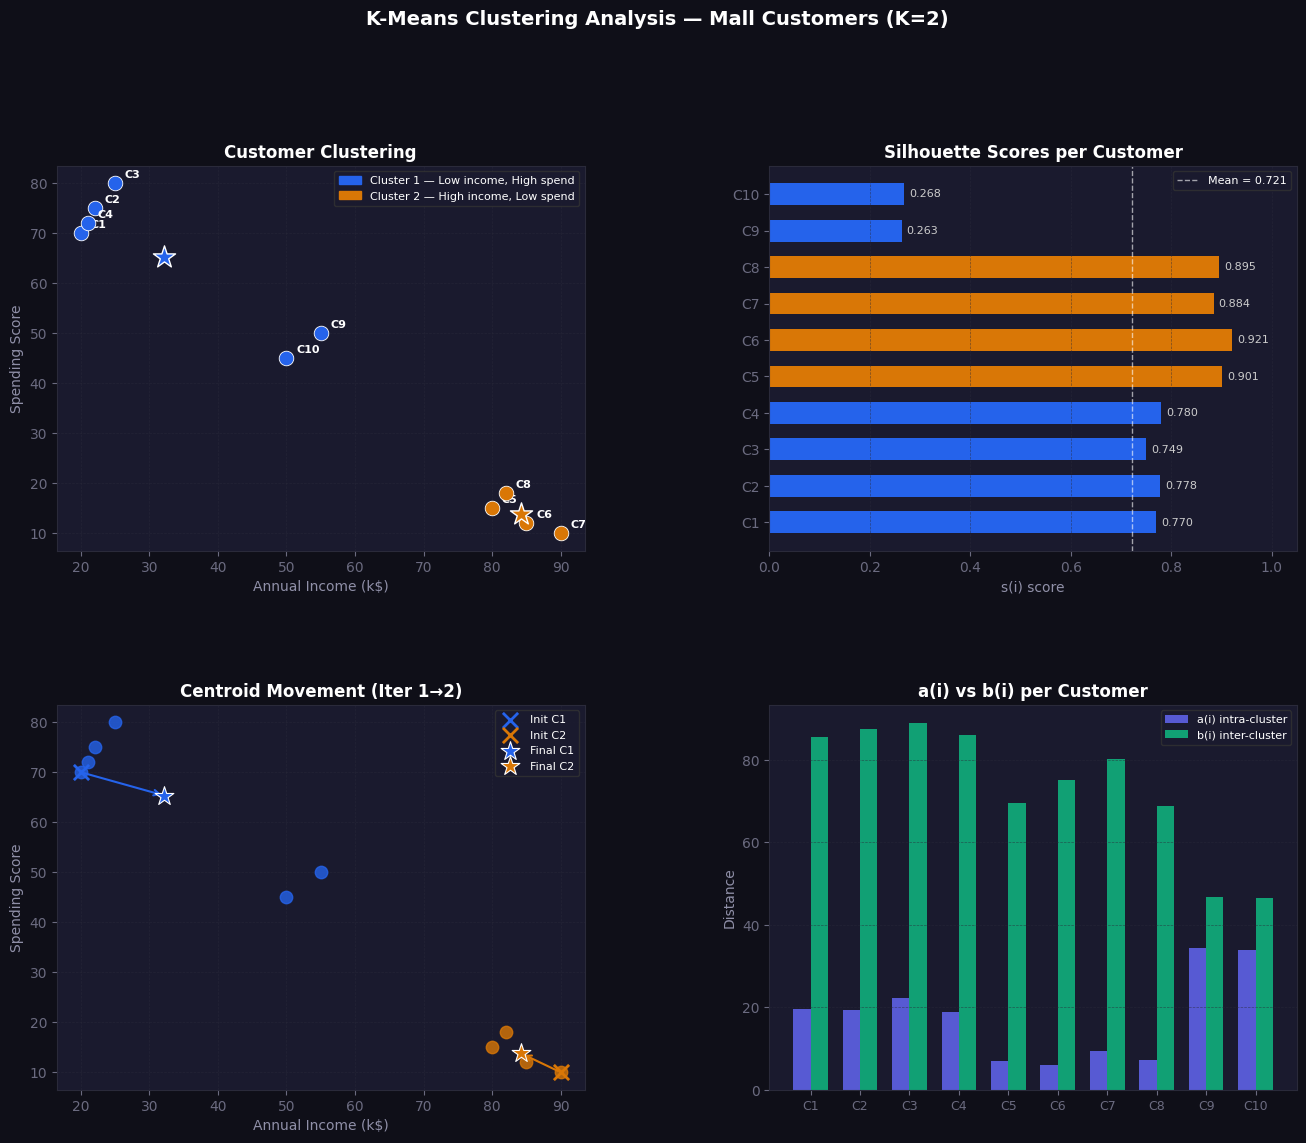

 Visualization saved as kmeans_visualization.png


In [12]:
# Color mapping
C1_COLOR = '#2563EB'   # blue   – Cluster 1
C2_COLOR = '#D97706'   # amber  – Cluster 2
C1_LIGHT = '#DBEAFE'
C2_LIGHT = '#FEF3C7'

colors = [C1_COLOR if c==1 else C2_COLOR for c in df['Cluster']]

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#0f0f18')
gs  = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Scatter ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#1a1a2e')
for i, row in df.iterrows():
    c = C1_COLOR if row['Cluster']==1 else C2_COLOR
    ax1.scatter(row['Income'], row['Score'], color=c, s=110, zorder=3, edgecolors='white', linewidths=0.6)
    ax1.annotate(row['ID'], (row['Income'], row['Score']),
                 textcoords='offset points', xytext=(7,4),
                 fontsize=8, color='white', fontweight='bold')

# Centroids
ax1.scatter(*new_c1, marker='*', s=280, color=C1_COLOR, edgecolors='white', linewidths=1, zorder=5, label='Centroid 1')
ax1.scatter(*new_c2, marker='*', s=280, color=C2_COLOR, edgecolors='white', linewidths=1, zorder=5, label='Centroid 2')

p1 = mpatches.Patch(color=C1_COLOR, label='Cluster 1 — Low income, High spend')
p2 = mpatches.Patch(color=C2_COLOR, label='Cluster 2 — High income, Low spend')
ax1.legend(handles=[p1,p2], loc='upper right', fontsize=8,
           facecolor='#1a1a2e', edgecolor='#333', labelcolor='white')
ax1.set_xlabel('Annual Income (k$)', color='#9090a8')
ax1.set_ylabel('Spending Score', color='#9090a8')
ax1.set_title('Customer Clustering', color='white', fontsize=12, fontweight='bold')
ax1.tick_params(colors='#6b6b80')
for sp in ax1.spines.values(): sp.set_color('#2a2a3a')
ax1.grid(color='#2a2a3a', linestyle='--', linewidth=0.5, alpha=0.6)

# ── Plot 2: Silhouette bars ──
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#1a1a2e')
bar_colors = [C1_COLOR if clusters2[i]==1 else C2_COLOR for i in range(len(ids))]
bars = ax2.barh(ids, s_vals, color=bar_colors, edgecolor='none', height=0.6)
ax2.axvline(s_vals.mean(), color='white', linestyle='--', linewidth=1, alpha=0.6, label=f'Mean = {s_vals.mean():.3f}')
for bar, val in zip(bars, s_vals):
    ax2.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8, color='#cccccc')
ax2.set_xlabel('s(i) score', color='#9090a8')
ax2.set_title('Silhouette Scores per Customer', color='white', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, facecolor='#1a1a2e', edgecolor='#333', labelcolor='white')
ax2.tick_params(colors='#6b6b80')
for sp in ax2.spines.values(): sp.set_color('#2a2a3a')
ax2.set_xlim(0, 1.05)
ax2.grid(axis='x', color='#2a2a3a', linestyle='--', linewidth=0.5, alpha=0.6)

# ── Plot 3: Iteration convergence path ──
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('#1a1a2e')
for i, row in df.iterrows():
    c = C1_COLOR if row['Cluster']==1 else C2_COLOR
    ax3.scatter(row['Income'], row['Score'], color=c, s=80, zorder=3, alpha=0.8)

# Centroid movement arrows
ax3.annotate('', xy=new_c1, xytext=centroid1,
             arrowprops=dict(arrowstyle='->', color=C1_COLOR, lw=1.5))
ax3.annotate('', xy=new_c2, xytext=centroid2,
             arrowprops=dict(arrowstyle='->', color=C2_COLOR, lw=1.5))
ax3.scatter(*centroid1, marker='x', s=120, color=C1_COLOR, linewidths=2, label='Init C1', zorder=5)
ax3.scatter(*centroid2, marker='x', s=120, color=C2_COLOR, linewidths=2, label='Init C2', zorder=5)
ax3.scatter(*new_c1, marker='*', s=200, color=C1_COLOR, edgecolors='white', linewidths=0.8, label='Final C1', zorder=6)
ax3.scatter(*new_c2, marker='*', s=200, color=C2_COLOR, edgecolors='white', linewidths=0.8, label='Final C2', zorder=6)
ax3.set_xlabel('Annual Income (k$)', color='#9090a8')
ax3.set_ylabel('Spending Score', color='#9090a8')
ax3.set_title('Centroid Movement (Iter 1→2)', color='white', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8, facecolor='#1a1a2e', edgecolor='#333', labelcolor='white')
ax3.tick_params(colors='#6b6b80')
for sp in ax3.spines.values(): sp.set_color('#2a2a3a')
ax3.grid(color='#2a2a3a', linestyle='--', linewidth=0.5, alpha=0.6)

# ── Plot 4: a(i) vs b(i) comparison ──
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('#1a1a2e')
x_pos = np.arange(len(ids))
width = 0.35
b1 = ax4.bar(x_pos - width/2, a_vals, width, label='a(i) intra-cluster', color='#6366f1', alpha=0.85)
b2 = ax4.bar(x_pos + width/2, b_vals, width, label='b(i) inter-cluster', color='#10b981', alpha=0.85)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(ids, color='#9090a8', fontsize=9)
ax4.set_ylabel('Distance', color='#9090a8')
ax4.set_title('a(i) vs b(i) per Customer', color='white', fontsize=12, fontweight='bold')
ax4.legend(fontsize=8, facecolor='#1a1a2e', edgecolor='#333', labelcolor='white')
ax4.tick_params(colors='#6b6b80')
for sp in ax4.spines.values(): sp.set_color('#2a2a3a')
ax4.grid(axis='y', color='#2a2a3a', linestyle='--', linewidth=0.5, alpha=0.6)

plt.suptitle('K-Means Clustering Analysis — Mall Customers (K=2)',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('kmeans_visualization.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f18')
plt.show()
print(" Visualization saved as kmeans_visualization.png")


6. Verification with scikit-learn

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_arr = df[['Income','Score']].values

# Use same initial centroids for reproducibility
km = KMeans(n_clusters=2,
            init=np.array([[20,70],[90,10]], dtype=float),
            n_init=1, max_iter=10, random_state=42)
km.fit(X_arr)

sk_labels   = km.labels_ + 1  # shift to 1-based
sk_sil      = silhouette_score(X_arr, km.labels_)
sk_centers  = km.cluster_centers_

print("=" * 55)
print("scikit-learn KMeans Verification")
print("=" * 55)
print(f"  Cluster labels : {dict(zip(ids, sk_labels))}")
print(f"  Centroid 1     : {np.round(sk_centers[0],4)}")
print(f"  Centroid 2     : {np.round(sk_centers[1],4)}")
print(f"  Silhouette     : {sk_sil:.6f}")
print(f"  Iterations     : {km.n_iter_}")
print()

match = np.array_equal(clusters2, sk_labels) or np.array_equal(clusters2, 3-sk_labels)
if match:
    print(" Manual results MATCH scikit-learn — calculation verified!")
else:
    print(" Label order may differ (cluster numbering can flip).")
    print("   Core grouping should still match.")


scikit-learn KMeans Verification
  Cluster labels : {'C1': np.int32(1), 'C2': np.int32(1), 'C3': np.int32(1), 'C4': np.int32(1), 'C5': np.int32(2), 'C6': np.int32(2), 'C7': np.int32(2), 'C8': np.int32(2), 'C9': np.int32(1), 'C10': np.int32(1)}
  Centroid 1     : [32.1667 65.3333]
  Centroid 2     : [84.25 13.75]
  Silhouette     : 0.721041
  Iterations     : 2

 Manual results MATCH scikit-learn — calculation verified!


7. Summary & Conclusion

In [14]:
print("=" * 60)
print("        FINAL SUMMARY — Making UI from my 10 dataset public")
print("=" * 60)
print()
print(f"  Dataset       : 10 Mall Customers")
print(f"  Features      : Annual Income (k$), Spending Score")
print(f"  K (clusters)  : 2")
print(f"  Init centroids: C1=(20,70), C2=(90,10)")
print(f"  Iterations    : 2 (converged)")
print()
c1_members = list(ids[clusters2==1])
c2_members = list(ids[clusters2==2])
print(f"  ● Cluster 1   : {c1_members}")
print(f"    Centroid    : ({new_c1[0]:.4f}, {new_c1[1]:.4f})")
print(f"    Profile     : Low income, High spending")
print()
print(f"  ● Cluster 2   : {c2_members}")
print(f"    Centroid    : ({new_c2[0]:.4f}, {new_c2[1]:.4f})")
print(f"    Profile     : High income, Low spending")
print()
print(f"  Silhouette    : {s_vals.mean():.6f} → Excellent separation ")
print()
print("=" * 60)


        FINAL SUMMARY — Making UI from my 10 dataset public

  Dataset       : 10 Mall Customers
  Features      : Annual Income (k$), Spending Score
  K (clusters)  : 2
  Init centroids: C1=(20,70), C2=(90,10)
  Iterations    : 2 (converged)

  ● Cluster 1   : ['C1', 'C2', 'C3', 'C4', 'C9', 'C10']
    Centroid    : (32.1667, 65.3333)
    Profile     : Low income, High spending

  ● Cluster 2   : ['C5', 'C6', 'C7', 'C8']
    Centroid    : (84.2500, 13.7500)
    Profile     : High income, Low spending

  Silhouette    : 0.721041 → Excellent separation 

